In [158]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
#note to self: matplotlib will give attribute errors for any function unless .pyplot is added to the import statement?

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report
import statsmodels.api as sm
from statsmodels.formula.api import ols, logit, mnlogit
import warnings
warnings.filterwarnings('ignore')

In [159]:
dataset =pd.read_csv('LinearRegressionDataset.csv')

Basic data clearning:

In [160]:
print(dataset.head(20))

print(dataset.shape)

dataset.drop_duplicates
dataset.dropna

print(dataset.shape)


          BMI        eGFR         LDL  Triglycerides
0   33.820262  148.245520  111.431559     205.697693
1   27.000786  161.390077  117.801032     104.851791
2   29.893690  173.734225   92.272411     177.450583
3   36.204466  164.273082   93.462600     112.614232
4   34.337790  160.487360  123.397381     130.294789
5   20.113611  139.199243  117.853865     175.730375
6   29.750442  171.894337  105.234493     145.659714
7   24.243214  152.129202  102.557514     105.369137
8   24.483906  137.301437   82.050749     150.681893
9   27.052993  149.067704   91.497815     168.933546
10  25.720218  152.554540  115.680868     206.126765
11  32.271368  149.195706  104.229286     165.570442
12  28.805189  151.769064   90.254435     179.584468
13  25.608375  143.199197  123.757120     187.388447
14  27.219316  152.516430   99.105756     153.520408
15  26.668372  149.886317   67.374087     177.773888
16  32.470395  168.805971  119.252620     120.749759
17  23.974209  135.684120  130.057006     113.

Beginning Linear regression tests:

the eGFR in the following 3 tests is always going to be the dependent variable as we want to observe how the
different factors such as BMI, LDL, and Triglycerides affect the eGFR.

To begin we plot a scatterplot to observe raw data trends.

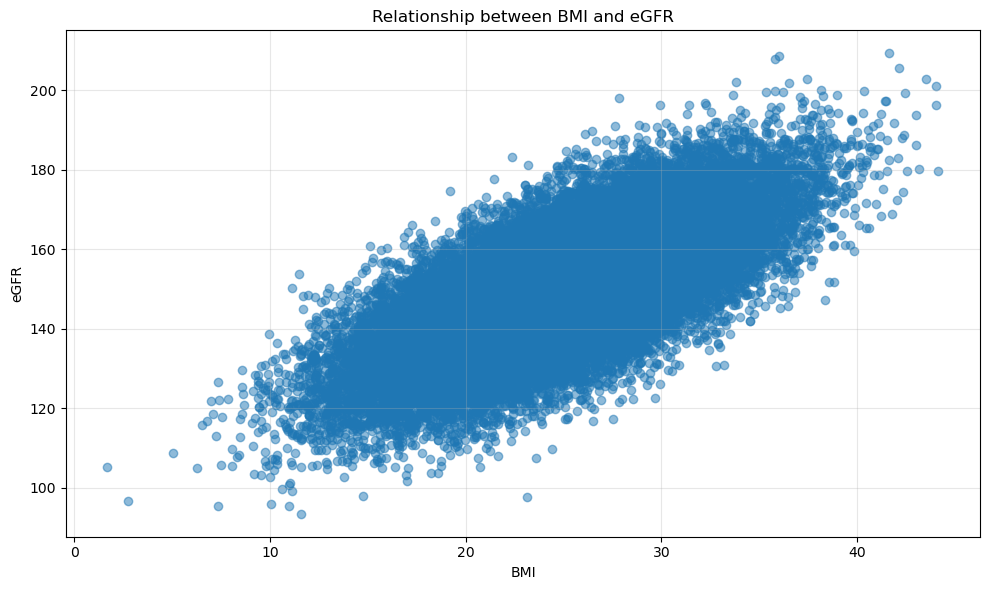

In [161]:
plt.figure(figsize=(10, 6))
plt.scatter(dataset['BMI'], dataset['eGFR'], alpha = 0.5)
plt.xlabel('BMI')
plt.ylabel('eGFR')
plt.title('Relationship between BMI and eGFR')
plt.grid(True, alpha=0.3)
plt.tight_layout()

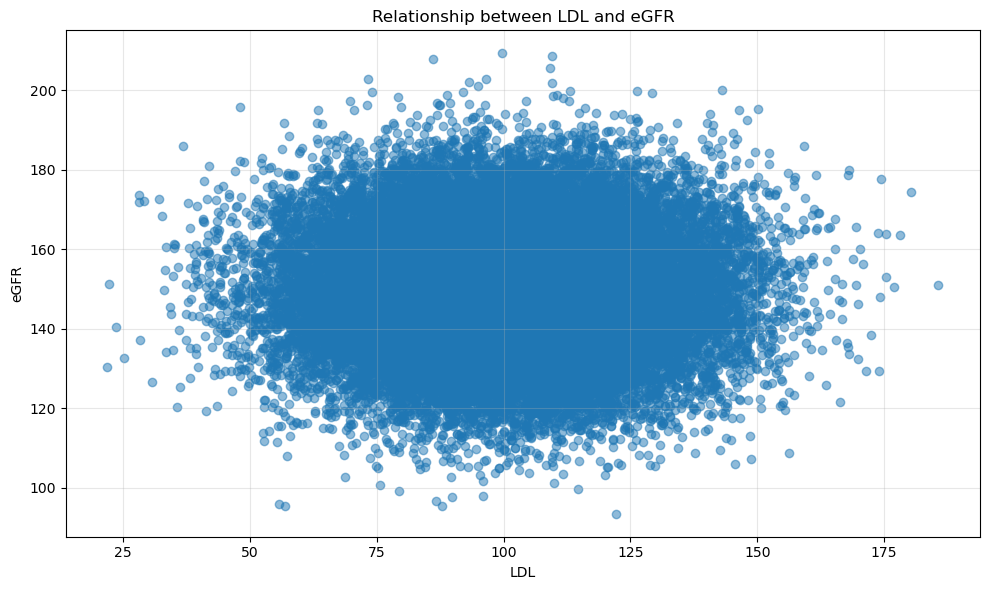

In [162]:
plt.figure(figsize=(10, 6))
plt.scatter(dataset['LDL'], dataset['eGFR'], alpha = 0.5)
plt.xlabel('LDL')
plt.ylabel('eGFR')
plt.title('Relationship between LDL and eGFR')
plt.grid(True, alpha=0.3)
plt.tight_layout()

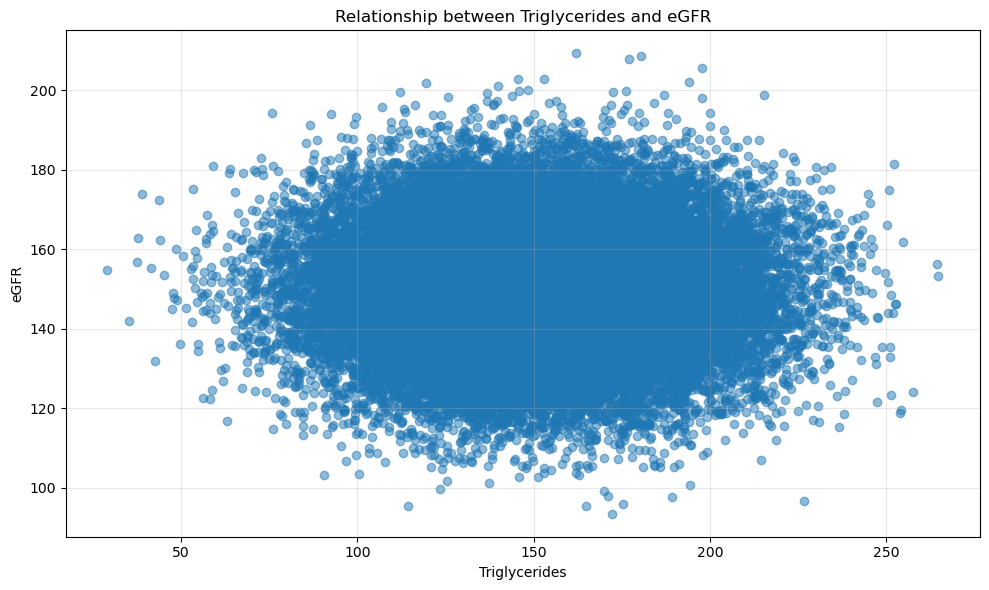

In [163]:
plt.figure(figsize=(10, 6))
plt.scatter(dataset['Triglycerides'], dataset['eGFR'], alpha = 0.5)
plt.xlabel('Triglycerides')
plt.ylabel('eGFR')
plt.title('Relationship between Triglycerides and eGFR')
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [164]:
#linear regression OLS regression process & results (BMI and eGFR)
X_simple = dataset[['BMI']]
y = dataset['eGFR']


X_simple_const = sm.add_constant(X_simple)


model_simple = sm.OLS(y, X_simple_const).fit()


print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                   eGFR   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                 4.066e+04
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:56:24   Log-Likelihood:            -1.4869e+05
No. Observations:               40000   AIC:                         2.974e+05
Df Residuals:                   39998   BIC:                         2.974e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         99.6279      0.255    391.454      0.0

In [165]:
#linear regression OLS regression process & results (triglycerides & eGFR)
X_simple = dataset[['Triglycerides']]
y = dataset['eGFR']


X_simple_const = sm.add_constant(X_simple)


model_simple = sm.OLS(y, X_simple_const).fit()


print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                   eGFR   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6105
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.435
Time:                        13:56:24   Log-Likelihood:            -1.6272e+05
No. Observations:               40000   AIC:                         3.254e+05
Df Residuals:                   39998   BIC:                         3.255e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           150.2332      0.362    415.065

In [166]:
#linear regression OLS regression process & results (triglycerides & eGFR)
X_simple = dataset[['LDL']]
y = dataset['eGFR']


X_simple_const = sm.add_constant(X_simple)


model_simple = sm.OLS(y, X_simple_const).fit()


print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                   eGFR   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2404
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.624
Time:                        13:56:24   Log-Likelihood:            -1.6272e+05
No. Observations:               40000   AIC:                         3.254e+05
Df Residuals:                   39998   BIC:                         3.255e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        150.1298      0.362    415.117      0.0

Regenerate graphs with linear regression line:

In [167]:
X = dataset[['BMI', 'LDL', 'Triglycerides']]
y= dataset['eGFR']
model = LinearRegression()
model.fit(X,y)
print(model.score(X,y))


0.5041268726477718


# Calculating the mean squared error of the dependent variable eGFR

In [168]:
# Naive prediction: use mean salary for everyone
mean_eGFR = dataset['eGFR'].mean()
print(f"Mean eGFR: ${mean_eGFR:,.2f}")

# Calculate errors for each observation
errors = dataset['eGFR'] - mean_eGFR
squared_errors = errors ** 2

# Create a small table to show the concept
error_table = pd.DataFrame({
    'Actual_eGFR': dataset['eGFR'][:5],
    'Predicted_eGFR': [mean_eGFR] * 5,
    'Error': errors[:5],
    'Squared_Error': squared_errors[:5]
})

print("\nExample of error calculations (first 5 observations):")
print(error_table.round(2))

# Calculate Mean Squared Error (MSE) for naive model
mse_naive = squared_errors.mean()
print(f"\nMean Squared Error (naive model using mean): {mse_naive:,.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse_naive):,.2f}")

Mean eGFR: $149.96

Example of error calculations (first 5 observations):
   Actual_eGFR  Predicted_eGFR  Error  Squared_Error
0       148.25          149.96  -1.71           2.93
1       161.39          149.96  11.43         130.74
2       173.73          149.96  23.78         565.41
3       164.27          149.96  14.32         204.98
4       160.49          149.96  10.53         110.91

Mean Squared Error (naive model using mean): 199.97
Root Mean Squared Error (RMSE): 14.14


# Preparing for LDL regression:

In [169]:
# Prepare data
X_LDL_simple = dataset['LDL']
y_LDL = dataset['eGFR']

# Add constant (intercept) for statsmodels
X_LDL_simple_const = sm.add_constant(X_LDL_simple)

# Fit model using statsmodels (gives us detailed statistics)
model_simple = sm.OLS(y_LDL, X_LDL_simple_const).fit()

# Print detailed results
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                   eGFR   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2404
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.624
Time:                        13:56:24   Log-Likelihood:            -1.6272e+05
No. Observations:               40000   AIC:                         3.254e+05
Df Residuals:                   39998   BIC:                         3.255e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        150.1298      0.362    415.117      0.0

In [170]:
# Make predictions
y_LDL_pred_simple = model_simple.predict(X_LDL_simple_const)

# Calculate errors
errors_lr = y_LDL - y_LDL_pred_simple
squared_errors_lr = errors_lr ** 2

# MSE for linear regression
mse_lr = squared_errors_lr.mean()

print(f"Mean Squared Error (linear regression): ${mse_lr:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${np.sqrt(mse_lr):,.2f}")
print(f"\nImprovement over naive model: {((mse_naive - mse_lr) / mse_naive * 100):.2f}%")

Mean Squared Error (linear regression): $199.97
Root Mean Squared Error (RMSE): $14.14

Improvement over naive model: 0.00%


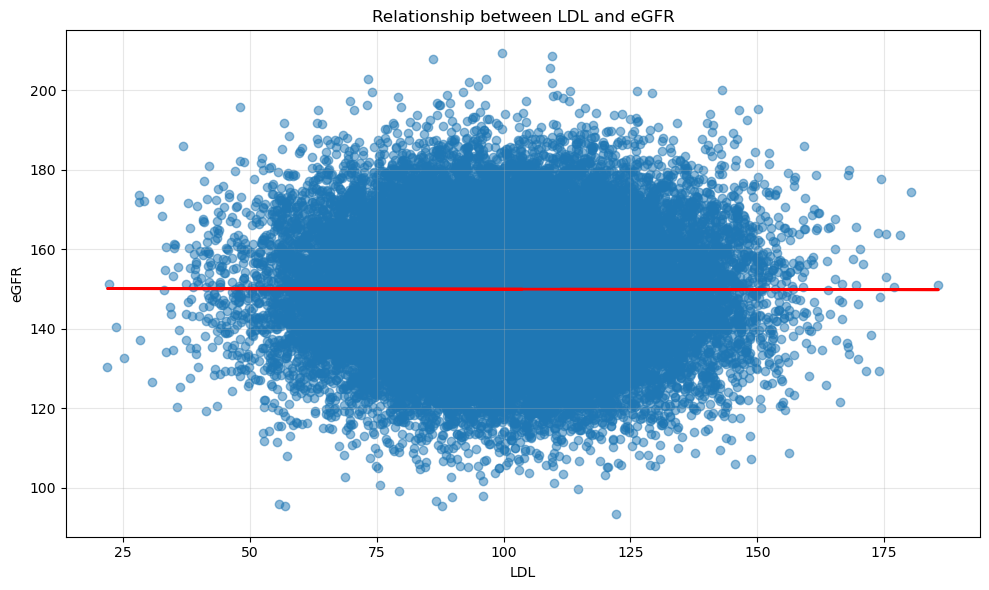

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(dataset['LDL'], dataset['eGFR'], alpha = 0.5)
plt.plot(dataset['LDL'], y_LDL_pred_simple, color='red', linewidth=2, label='Regression line')
plt.xlabel('LDL')
plt.ylabel('eGFR')
plt.title('Relationship between LDL and eGFR')
plt.grid(True, alpha=0.3)
plt.tight_layout()
print("The results suggest that the relationship between LDL and eGFR is statistically insignificant")
print("p value:0.624 , t value: -0.490 ")

# regression line for BMI:

In [172]:
# Prepare data
X_BMI_simple = dataset['BMI']
y_BMI = dataset['eGFR']

# Add constant (intercept) for statsmodels
X_BMI_simple_const = sm.add_constant(X_BMI_simple)

# Fit model using statsmodels (gives us detailed statistics)
model_simple = sm.OLS(y_BMI, X_BMI_simple_const).fit()

# Print detailed results
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                   eGFR   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                 4.066e+04
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:56:24   Log-Likelihood:            -1.4869e+05
No. Observations:               40000   AIC:                         2.974e+05
Df Residuals:                   39998   BIC:                         2.974e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         99.6279      0.255    391.454      0.0

In [173]:
# Make predictions
y_BMI_pred_simple = model_simple.predict(X_BMI_simple_const)

# Calculate errors
errors_lr = y_BMI - y_BMI_pred_simple
squared_errors_lr = errors_lr ** 2

# MSE for linear regression
mse_lr = squared_errors_lr.mean()

print(f"Mean Squared Error (linear regression): ${mse_lr:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${np.sqrt(mse_lr):,.2f}")
print(f"\nImprovement over naive model: {((mse_naive - mse_lr) / mse_naive * 100):.2f}%")

Mean Squared Error (linear regression): $99.16
Root Mean Squared Error (RMSE): $9.96

Improvement over naive model: 50.41%


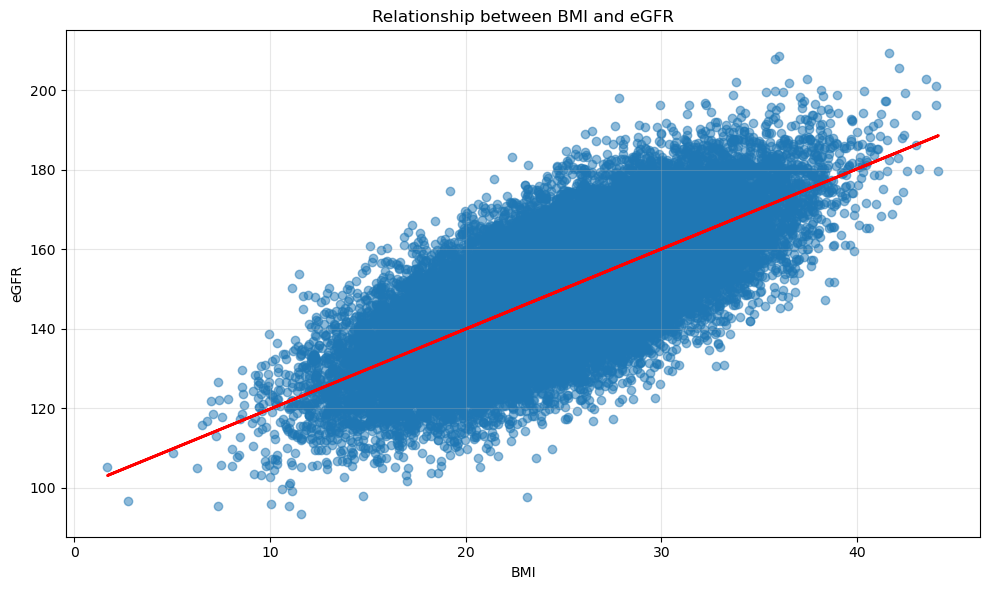

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(dataset['BMI'], dataset['eGFR'], alpha = 0.5)
plt.plot(dataset['BMI'], y_BMI_pred_simple, color='red', linewidth=2, label='Regression line')
plt.xlabel('BMI')
plt.ylabel('eGFR')
plt.title('Relationship between BMI and eGFR')
plt.grid(True, alpha=0.3)
plt.tight_layout()
print("The results suggest that the relationship between BMI and eGFR is statistically significant.")
print("p value:0.000 , t value: 201.644  ")

# regression line for triglycerides:

In [175]:
# Prepare data
X_TRI_simple = dataset['Triglycerides']
y_TRI = dataset['eGFR']

# Add constant (intercept) for statsmodels
X_TRI_simple_const = sm.add_constant(X_TRI_simple)

# Fit model using statsmodels (gives us detailed statistics)
model_simple = sm.OLS(y_TRI, X_TRI_simple_const).fit()

# Print detailed results
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                   eGFR   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6105
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.435
Time:                        13:56:24   Log-Likelihood:            -1.6272e+05
No. Observations:               40000   AIC:                         3.254e+05
Df Residuals:                   39998   BIC:                         3.255e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           150.2332      0.362    415.065

In [176]:
# Make predictions
y_TRI_pred_simple = model_simple.predict(X_TRI_simple_const)

# Calculate errors
errors_lr = y_TRI - y_TRI_pred_simple
squared_errors_lr = errors_lr ** 2

# MSE for linear regression
mse_lr = squared_errors_lr.mean()

print(f"Mean Squared Error (linear regression): ${mse_lr:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${np.sqrt(mse_lr):,.2f}")
print(f"\nImprovement over naive model: {((mse_naive - mse_lr) / mse_naive * 100):.2f}%")

Mean Squared Error (linear regression): $199.97
Root Mean Squared Error (RMSE): $14.14

Improvement over naive model: 0.00%


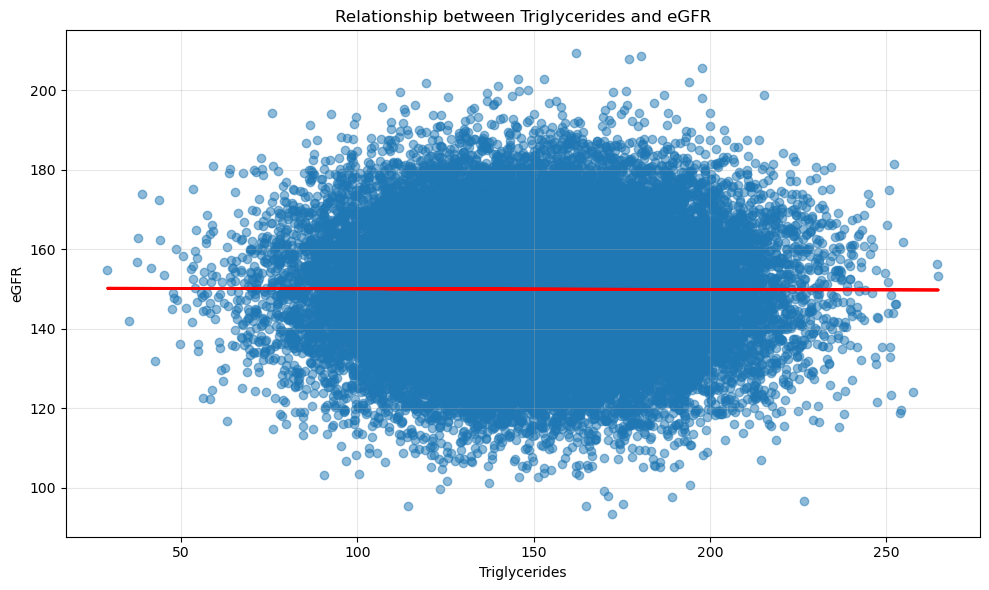

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(dataset['Triglycerides'], dataset['eGFR'], alpha = 0.5)
plt.plot(dataset['Triglycerides'], y_TRI_pred_simple, color='red', linewidth=2, label='Regression line')
plt.xlabel('Triglycerides')
plt.ylabel('eGFR')
plt.title('Relationship between Triglycerides and eGFR')
plt.grid(True, alpha=0.3)
plt.tight_layout()
print("The results suggest that the relationship between Triglycerides and eGFR is statistically significant.")
print("p value: 0.435 , t value:  -0.781  ")
  